# Check a targets observability with N-CAMs and F-CAMs

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [3]:
# Python standard
import os
import sys
import glob

# PlatoSim standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.coordinates import SkyCoord
from astropy import units as u

# PlatoSim functions
import platosim.plot      as pt
import platosim.utilities as ut 
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.utilities    import getFunctions
from platosim.matplotlibrc import setup_notebook
setup_notebook()

# Configure notebook 
from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [4]:
path = ut.getHomeDir('inputfiles/data_picsim')

In [33]:
dt = pd.read_feather(path / 'PIC220_LOPS2_targets.ftr')
ds = pd.read_feather(path / 'LOPS2_FCAM.ftr')
ds.columns

Index(['starID', 'PIC', 'gaiaDR3', 'l', 'b', 'ra', 'dec', 'pmra', 'pmdec',
       'Pmag', 'PBmag', 'PRmag', 'M', 'R', 'Teff', 'logg', 'ncams', 'case',
       'source', 'tPIC', 'fgPIC', 'cPIC', 'scvPIC', 'flux', 'xCCD', 'yCCD',
       'xFP', 'yFP', 'rOA'],
      dtype='object')

In [8]:
names = [
    'Gaia DR3 4792774797545800832',
]

In [16]:
# Query sources from Gaia DR3 database
df = pd.DataFrame()
for n in names:
    try:
        dx = sq.simbadQuery(n, radius=15, maglim=21)
        dx['name'] = n
    except:
        print(n)
        pass
    else:
        df = pd.concat([df, dx.iloc[0].to_frame().T])

# Current data frame
cols = list(df)
cols.insert(0, cols.pop(cols.index('name')))
df = df.loc[:, cols]
df = df.drop(columns=['dis'])
df = df.reset_index(drop=True)

# Add galactic coordinates
gal = SkyCoord(df.ra, df.dec, frame='icrs', unit=u.deg).galactic
df['l'] = gal.l.deg
df['b'] = gal.b.deg
df

,name,gaiaDR3,ra,dec,Gmag,BP_RP,plx,plxe,pmra,pmdec,ruwe,teff,logg,Pmag,l,b
0,Gaia DR3 4792774797545800832,4792774797545800832,86.821235,-51.066136,3.823242,0.261432,50.930691,0.148211,5.160197,84.04053,3.071663,7938.053223,4.2095,3.733565,258.363399,-30.611669


<IPython.core.display.Javascript object>


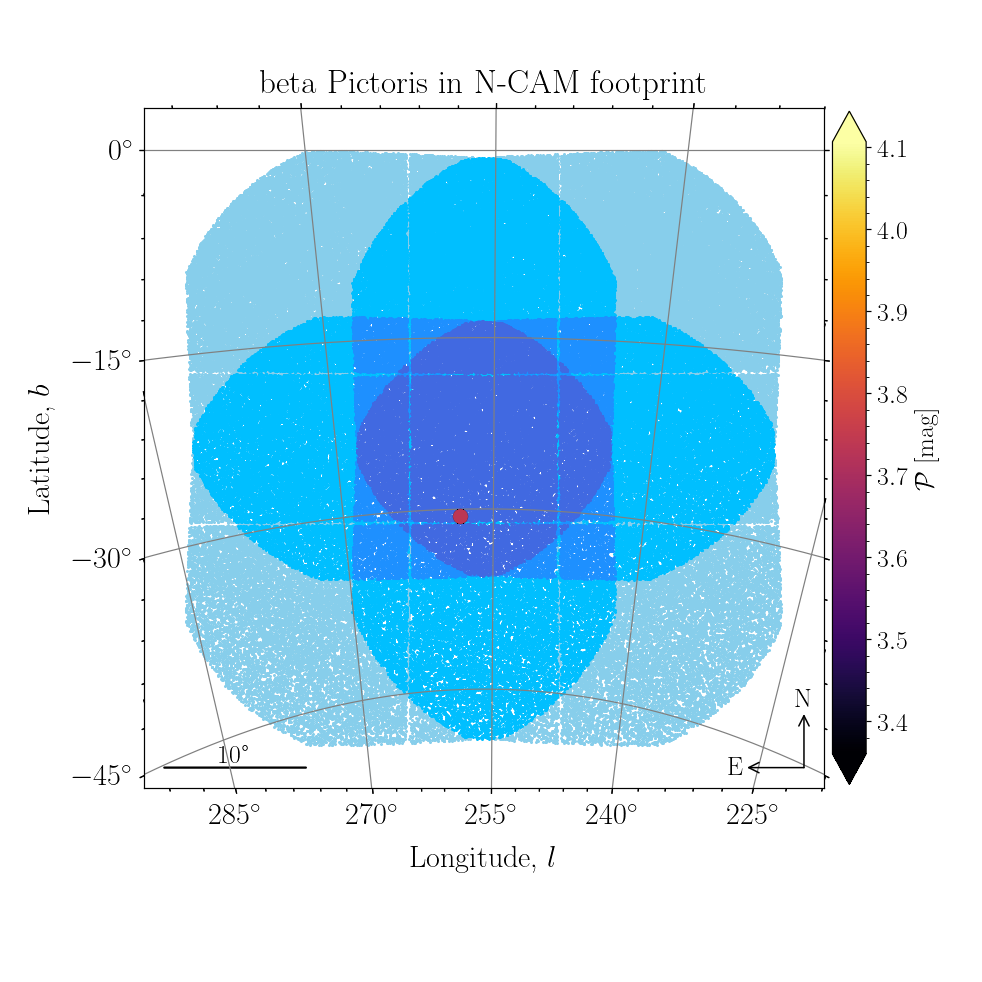

In [21]:
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=30, ncamStars=dt,
    # Plot stars
    raStars=df.ra, decStars=df.dec, c=df.Pmag, s=400, 
    cmap='inferno', clabel=r'$\mathcal{P}$ [mag]', 
    # Settings
    figsize=(9,9), title='beta Pictoris in N-CAM footprint'
)


<IPython.core.display.Javascript object>


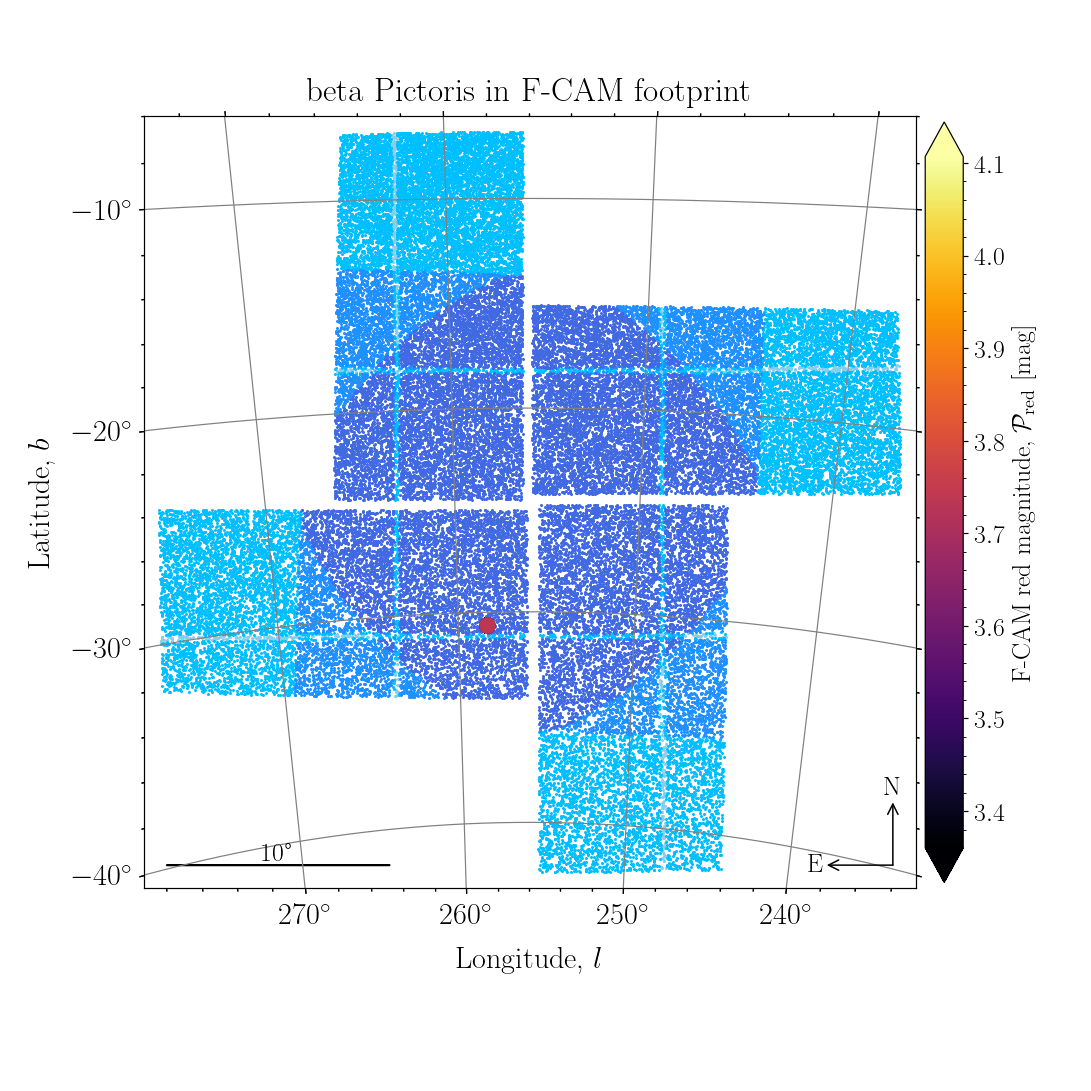

In [38]:
fig, ax = pt.plotPlatoFOV(
    # Plot skymap
    'LOPS2', system='galactic', fovSize=19, ncamStars=ds,
    # Plot stars
    raStars=df.ra, decStars=df.dec, c=df.Pmag, s=500, 
    cmap='inferno', clabel=r'F-CAM red magnitude, $\mathcal{P}_{\rm red}$ [mag]', 
    # Settings
    figsize=(10,10), title='beta Pictoris in F-CAM footprint'
)
fig.savefig(path / 'flower_LOPS2_FCAM_betaPictoris.png', bbox_inches='tight', dpi=200)